DataFrame 'df_full' já carregado.
Calculando tokens globais...

--- Tabela Resumo Global do Dataset ---


Métrica,Valor
Nº Total de Amostras,250365
Nº Total de Tokens,1373582
Nº Tokens Distintos (Vocabulário),52651
Nº Classes Únicas,795



--- Análise das Top 10 Classes Mais Frequentes ---
Top 10 Classes (Nome da Classe: Nº de Amostras):
  - BISCOITO: 14292
  - IOGURTE: 7520
  - CHOCOLATE: 6732
  - PADARIA E CONFEITARIA INDUSTRIALIZADO: 6046
  - APERITIVO: 5186
  - SABONETE: 5135
  - CERVEJA: 5120
  - MACARRAO: 5019
  - SUCO PRONTO: 5017
  - CAFE: 4811

--- Tabela Resumo por Top 10 Classes ---


Classe,Nº Amostras,Nº Total Tokens na Classe,Nº Tokens Distintos na Classe,Razão de Tokens Distintos
BISCOITO,14292,77261,4056,0.052497
IOGURTE,7520,43747,2222,0.050792
CHOCOLATE,6732,37163,2360,0.063504
PADARIA E CONFEITARIA INDUSTRIALIZADO,6046,33135,2574,0.077682
APERITIVO,5186,26535,1821,0.068626
SABONETE,5135,29849,2226,0.074575
CERVEJA,5120,26550,1339,0.050433
MACARRAO,5019,28445,1979,0.069573
SUCO PRONTO,5017,27502,1292,0.046978
CAFE,4811,28368,1856,0.065426


C:\Users\ghdaru\AppData\Local\Temp\ipykernel_2716\2465816263.py:156: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_top_classes_summary["Classe"], y=df_top_classes_summary["Nº Amostras"], palette="viridis")


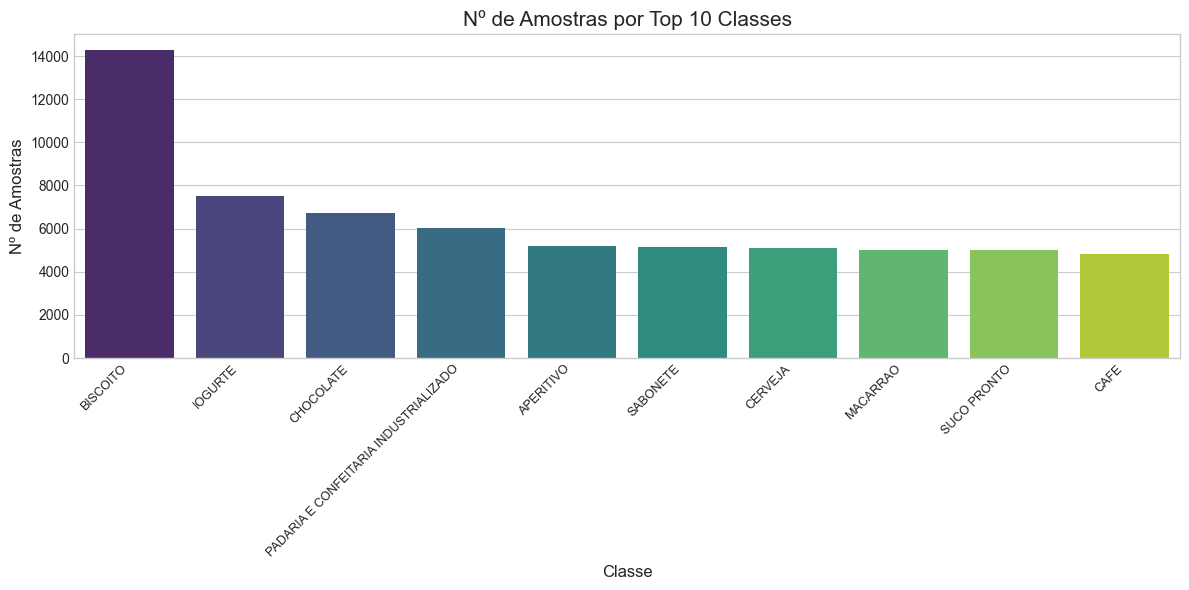

C:\Users\ghdaru\AppData\Local\Temp\ipykernel_2716\2465816263.py:166: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_top_classes_summary["Classe"], y=df_top_classes_summary["Nº Total Tokens na Classe"], palette="magma")


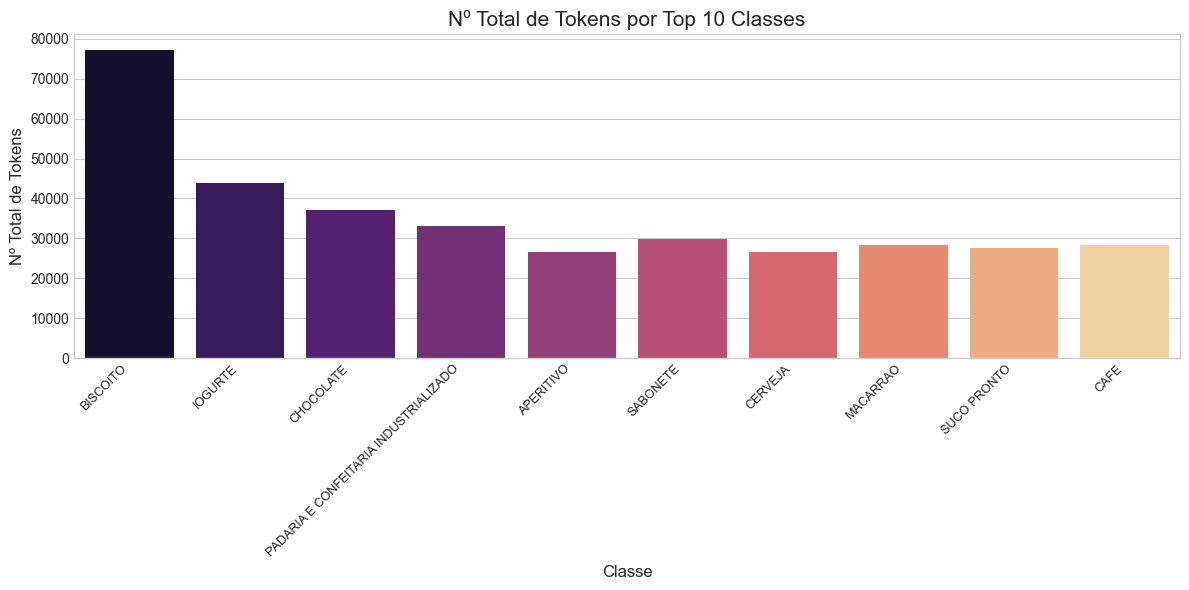

C:\Users\ghdaru\AppData\Local\Temp\ipykernel_2716\2465816263.py:176: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_top_classes_summary["Classe"], y=df_top_classes_summary["Nº Tokens Distintos na Classe"], palette="coolwarm")


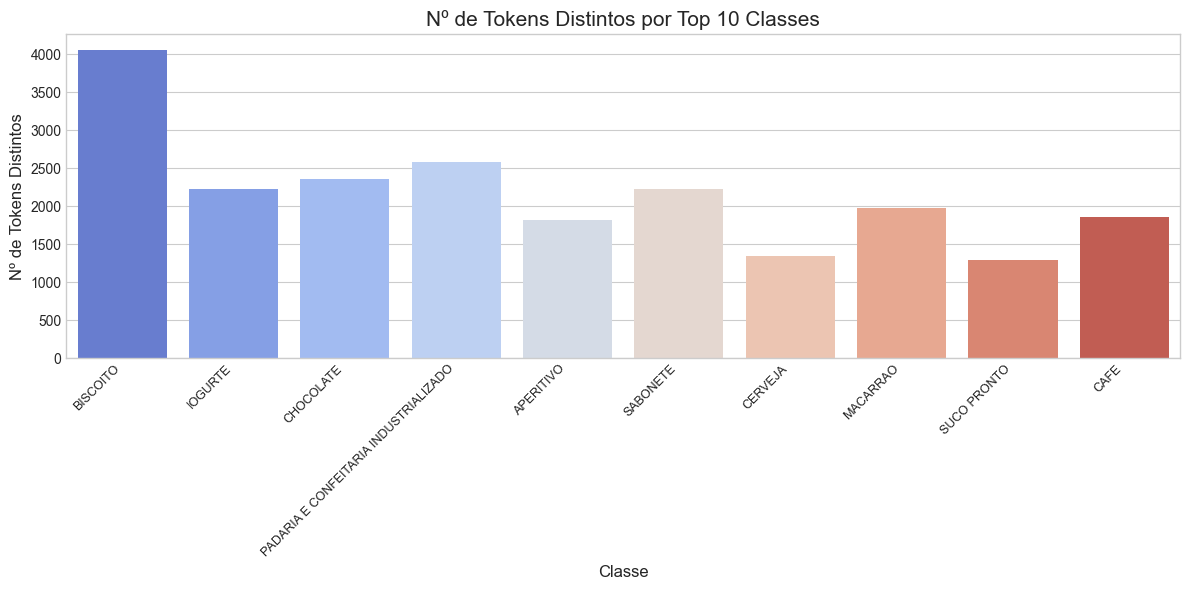

In [3]:
# -*- coding: utf-8 -*-
# ---
# jupyter:
#   jupytext:
#     text_representation:
#       extension: .py
#       format_name: light
#       format_version: '1.5'
#       jupytext_version: 1.14.5
#   kernelspec:
#     display_name: Python 3 (ipykernel)
#     language: python
#     name: python3
# ---

# # Análise de Características do Dataset e Correlações

# ## 1. Configurações e Imports
# (Manter como antes, assegurando pandas, numpy, matplotlib.pyplot, seaborn, Counter)
# +
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import glob
from collections import Counter

# ... (outros imports como scipy, statsmodels, sys, etc. podem ser mantidos se usados em outras seções) ...

# sns.set_theme(style="whitegrid") # Já definido antes, se esta for uma célula separada
# plt.rcParams['figure.figsize'] = (10, 6) # Ajuste para histogramas
# ... (outros rcParams) ...
# -

# ## 2. Definição de Parâmetros e Caminhos
# (Manter como antes, assegurando FULL_DATASET_FILE, TEXT_COLUMN, LABEL_COLUMN)
# +
# ... (Parâmetros como base_ag_results_path, AVAILABLE_L0_SIZES, etc. mantidos) ...
FULL_DATASET_FILE = os.path.join("..", "data", "dataset.csv") 
TEXT_COLUMN = 'nm_item' 
LABEL_COLUMN = 'nm_product'
# ... (outros parâmetros) ...
# -

# ## 3. Carregamento do Dataset Completo
# (Garantir que df_full seja carregado aqui se não foi antes)

# +
if 'df_full' not in locals() or df_full is None or df_full.empty:
    print("DataFrame 'df_full' não carregado. Tentando carregar...")
    try:
        df_full = pd.read_csv(FULL_DATASET_FILE)
        df_full.dropna(subset=[TEXT_COLUMN, LABEL_COLUMN], inplace=True)
        # Aplicar qualquer pré-processamento de label que foi usado no AG, se houver.
        # Ex: df_full[LABEL_COLUMN] = df_full[LABEL_COLUMN].astype(str).str.lower().str.strip()
        print(f"Dataset completo carregado de: {FULL_DATASET_FILE} com {len(df_full)} amostras.")
    except FileNotFoundError:
        print(f"ERRO CRÍTICO: Dataset completo não encontrado em {FULL_DATASET_FILE}. Análise de características do dataset não pode prosseguir.")
        df_full = pd.DataFrame() # Para evitar erros subsequentes
    except Exception as e:
        print(f"ERRO CRÍTICO ao carregar o dataset completo: {e}")
        df_full = pd.DataFrame()
else:
    print("DataFrame 'df_full' já carregado.")

# Assegurar que as colunas de texto e label são strings
if not df_full.empty:
    df_full[TEXT_COLUMN] = df_full[TEXT_COLUMN].astype(str)
    df_full[LABEL_COLUMN] = df_full[LABEL_COLUMN].astype(str)
# -

# ## Análise Descritiva do Dataset Completo (NOVA SEÇÃO)

# ### Tabela Resumo Global do Dataset

# +
if not df_full.empty:
    num_total_amostras = len(df_full)
    
    # Calcular tokens globais (pode demorar para datasets grandes)
    print("Calculando tokens globais...")
    all_texts_global = " ".join(df_full[TEXT_COLUMN].tolist())
    tokens_global = all_texts_global.lower().split() # Tokenização simples por espaço e minúsculas
    num_total_tokens_global = len(tokens_global)
    num_distinct_tokens_global = len(set(tokens_global))
    
    num_classes_unicas_global = df_full[LABEL_COLUMN].nunique()

    global_summary_data = {
        "Métrica": ["Nº Total de Amostras", "Nº Total de Tokens", "Nº Tokens Distintos (Vocabulário)", "Nº Classes Únicas"],
        "Valor": [num_total_amostras, num_total_tokens_global, num_distinct_tokens_global, num_classes_unicas_global]
    }
    df_global_summary = pd.DataFrame(global_summary_data)
    
    print("\n--- Tabela Resumo Global do Dataset ---")
    try:
        from IPython.display import display, HTML
        display(HTML(df_global_summary.to_html(index=False, classes='table table-striped')))
    except ImportError:
        print(df_global_summary.to_string(index=False))
else:
    print("DataFrame 'df_full' está vazio. Não é possível gerar resumo global.")
# -

# ### Análise das Top 10 Classes Mais Frequentes

# +
if not df_full.empty:
    print("\n--- Análise das Top 10 Classes Mais Frequentes ---")
    
    # Contar ocorrências de cada classe
    class_counts = df_full[LABEL_COLUMN].value_counts()
    top_10_classes = class_counts.nlargest(10)
    
    print("Top 10 Classes (Nome da Classe: Nº de Amostras):")
    for class_name, count in top_10_classes.items():
        print(f"  - {class_name}: {count}")

    top_classes_summary_data = []
    for class_name in top_10_classes.index:
        df_class_subset = df_full[df_full[LABEL_COLUMN] == class_name]
        
        num_amostras_classe = len(df_class_subset)
        
        # Calcular tokens para esta classe
        texts_classe = " ".join(df_class_subset[TEXT_COLUMN].tolist())
        tokens_classe = texts_classe.lower().split()
        num_total_tokens_classe = len(tokens_classe)
        num_distinct_tokens_classe = len(set(tokens_classe))
        
        top_classes_summary_data.append({
            "Classe": class_name,
            "Nº Amostras": num_amostras_classe,
            "Nº Total Tokens na Classe": num_total_tokens_classe,
            "Nº Tokens Distintos na Classe": num_distinct_tokens_classe,
            "Razão de Tokens Distintos": num_distinct_tokens_classe / num_total_tokens_classe if num_total_tokens_classe > 0 else 0
        })
        
    df_top_classes_summary = pd.DataFrame(top_classes_summary_data)
    
    print("\n--- Tabela Resumo por Top 10 Classes ---")
    if not df_top_classes_summary.empty:
        try:
            from IPython.display import display, HTML
            display(HTML(df_top_classes_summary.to_html(index=False, classes='table table-striped')))
        except ImportError:
            print(df_top_classes_summary.to_string(index=False))
            
        # --- Histogramas/Bar Plots para Top 10 Classes ---
        plt.style.use('seaborn-v0_8-whitegrid') # Usar estilo do seaborn para os plots

        # Histograma 1: Número de Amostras por Top Classe
        plt.figure(figsize=(12, 6))
        sns.barplot(x=df_top_classes_summary["Classe"], y=df_top_classes_summary["Nº Amostras"], palette="viridis")
        plt.title("Nº de Amostras por Top 10 Classes", fontsize=15)
        plt.xlabel("Classe", fontsize=12)
        plt.ylabel("Nº de Amostras", fontsize=12)
        plt.xticks(rotation=45, ha="right", fontsize=9)
        plt.tight_layout()
        plt.show()

        # Histograma 2: Número Total de Tokens por Top Classe
        plt.figure(figsize=(12, 6))
        sns.barplot(x=df_top_classes_summary["Classe"], y=df_top_classes_summary["Nº Total Tokens na Classe"], palette="magma")
        plt.title("Nº Total de Tokens por Top 10 Classes", fontsize=15)
        plt.xlabel("Classe", fontsize=12)
        plt.ylabel("Nº Total de Tokens", fontsize=12)
        plt.xticks(rotation=45, ha="right", fontsize=9)
        plt.tight_layout()
        plt.show()

        # Histograma 3: Número de Tokens Distintos por Top Classe
        plt.figure(figsize=(12, 6))
        sns.barplot(x=df_top_classes_summary["Classe"], y=df_top_classes_summary["Nº Tokens Distintos na Classe"], palette="coolwarm")
        plt.title("Nº de Tokens Distintos por Top 10 Classes", fontsize=15)
        plt.xlabel("Classe", fontsize=12)
        plt.ylabel("Nº de Tokens Distintos", fontsize=12)
        plt.xticks(rotation=45, ha="right", fontsize=9)
        plt.tight_layout()
        plt.show()
        
    else:
        print("  Nenhum dado para a tabela de resumo das top 10 classes.")
        
else:
    print("DataFrame 'df_full' está vazio. Não é possível gerar análise descritiva do dataset.")

# -

# ## (Seções Anteriores de Correlação e Outras Análises)
# ...

# ## Fim da Análise